## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Load Clean Data

In [9]:
BASE_DIR = Path("../../")
CLEAN_DATA = BASE_DIR / "data/cleaned"

inflation = pd.read_csv(CLEAN_DATA / "inflation.csv")

### Convert Date

In [11]:
inflation["date"] = pd.to_datetime(inflation["date"])
inflation = inflation.sort_values("date")

### Inspect

In [12]:
inflation.head()

,year,month,annual_average_inflation,12_month_inflation,date
0,2005,January,12.27,14.87,2005-01-01
1,2005,February,12.60,13.94,2005-02-01
2,2005,March,13.07,14.15,2005-03-01
3,2005,April,13.76,16.02,2005-04-01
4,2005,May,14.61,14.78,2005-05-01


## Inflation Trend (Level)

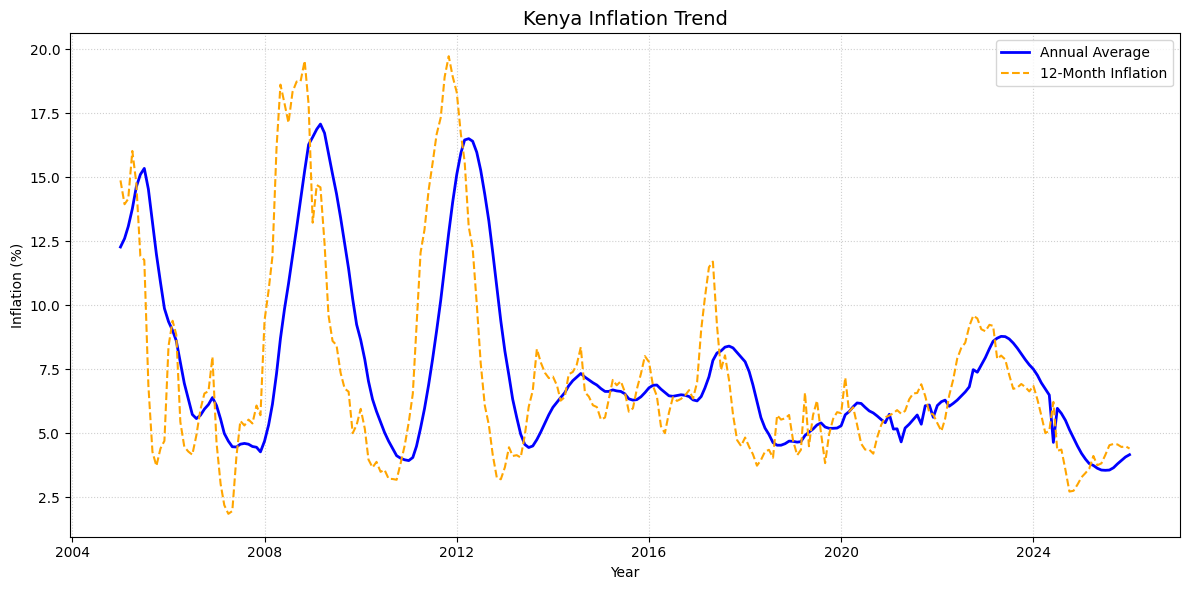

In [23]:


# Plotting
plt.figure(figsize=(12, 6))
plt.plot(inflation["date"], inflation["annual_average_inflation"], label="Annual Average", color='blue', linewidth=2)

# Adding the 12-Month Inflation for comparison
plt.plot(inflation["date"], inflation["12_month_inflation"], label="12-Month Inflation", color='orange', linestyle='--')

plt.title("Kenya Inflation Trend", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

This chart shows the long-term evolution of inflation in Kenya. Peaks may correspond to supply shocks, fuel price increases, droughts, political situation or currency depreciation.

## 1. Acceleration & Momentum
In economics, Momentum is the first derivative (rate of change), and Acceleration is the second derivative (change in the rate of change).

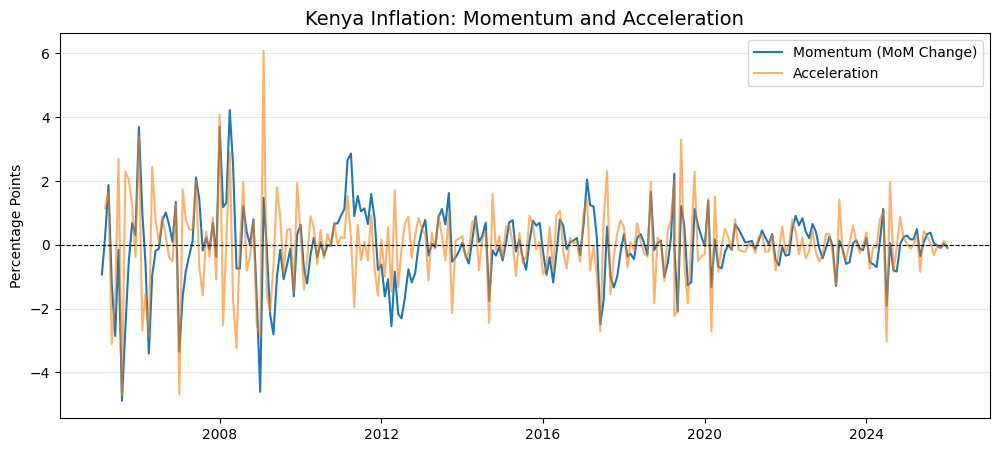

In [31]:
# Momentum: Month-on-Month change in the Annual Average
inflation['momentum'] = inflation['12_month_inflation'].diff()

# Acceleration: Change in momentum
inflation['acceleration'] = inflation['momentum'].diff()

# Calculations
inflation['momentum'] = inflation['12_month_inflation'].diff()
inflation['acceleration'] = inflation['momentum'].diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(inflation["date"], inflation["momentum"], label="Momentum (MoM Change)", color='#1f77b4')
plt.plot(inflation["date"], inflation["acceleration"], label="Acceleration", color='#ff7f0e', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Kenya Inflation: Momentum and Acceleration", fontsize=14)
plt.ylabel("Percentage Points")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Rolling Volatility
This shows how much the inflation rate "swings" over a window of time. A 12-month rolling standard deviation is the standard way to measure this.

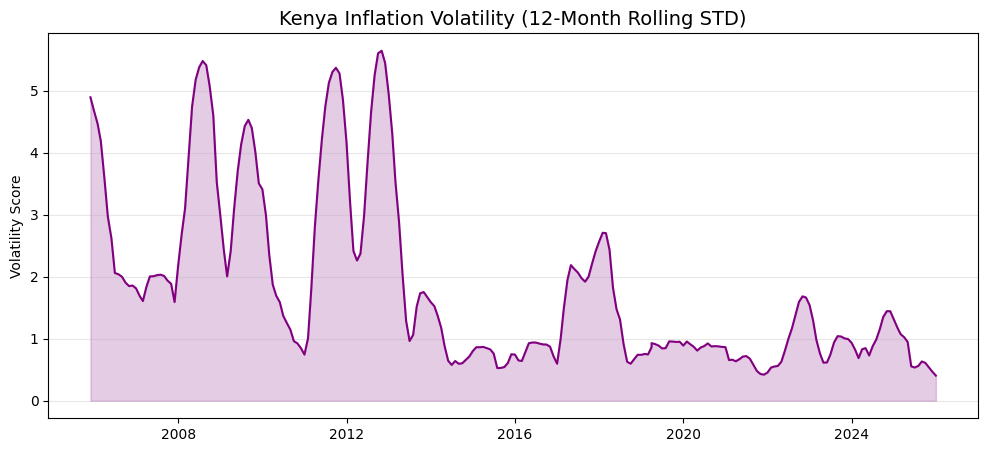

In [32]:
# 12-month rolling volatility
inflation['volatility'] = inflation['12_month_inflation'].rolling(window=12).std()

# 12-month rolling standard deviation
inflation['volatility'] = inflation['12_month_inflation'].rolling(window=12).std()

plt.figure(figsize=(12, 5))
plt.fill_between(inflation["date"], inflation["volatility"], color='purple', alpha=0.2)
plt.plot(inflation["date"], inflation["volatility"], color='purple', linewidth=1.5)
plt.title("Kenya Inflation Volatility (12-Month Rolling STD)", fontsize=14)
plt.ylabel("Volatility Score")
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. Inflation Regimes
Categorized periods into "Low", "Moderate", and "High" inflation. These thresholds are often aligned with Central Bank targets (e.g., target is $5.0\% \pm 2.5\%$).

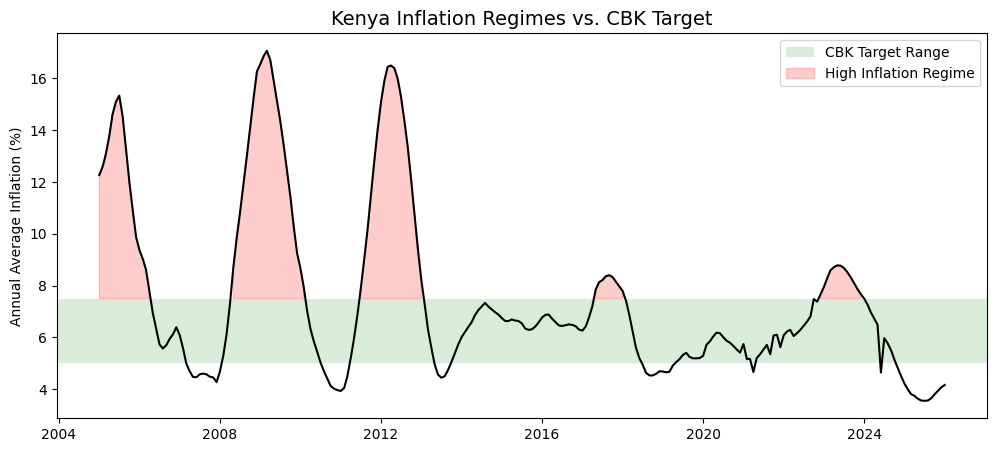

In [33]:
def categorize_regime(rate):
    if rate < 5.0: return 'Low'
    elif 5.0 <= rate <= 7.5: return 'Target'
    else: return 'High'

inflation['regime'] = inflation['annual_average_inflation'].apply(categorize_regime)

plt.figure(figsize=(12, 5))
# Plot the main trend
plt.plot(inflation["date"], inflation["annual_average_inflation"], color='black', zorder=2)

# Highlight the Target Zone
plt.axhspan(5.0, 7.5, facecolor='green', alpha=0.15, label='CBK Target Range')

# Identify "High" periods (above 7.5)
plt.fill_between(inflation["date"], inflation["annual_average_inflation"], 7.5, 
                 where=(inflation["annual_average_inflation"] > 7.5), 
                 color='red', alpha=0.2, label='High Inflation Regime')

plt.title("Kenya Inflation Regimes vs. CBK Target", fontsize=14)
plt.ylabel("Annual Average Inflation (%)")
plt.legend()
plt.show()

## 4. Seasonal Monthly Averages
This helps identify if certain months (like December due to spending or April due to taxes/rainy season) consistently have higher inflation.

<Axes: title={'center': 'Average Inflation by Month'}, xlabel='month'>

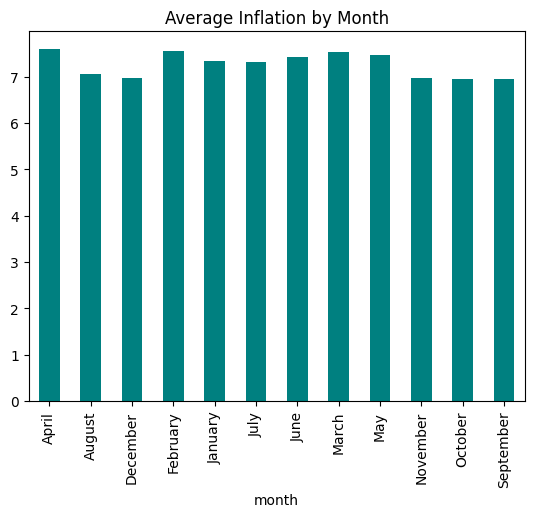

In [27]:
# Group by month and calculate mean
seasonal_analysis = inflation.groupby('month')['12_month_inflation'].mean()

# Plotting the seasonality
seasonal_analysis.plot(kind='bar', color='teal', title='Average Inflation by Month')